# Transformación y análisis de datos
Análisis de la posible correlación entre los datos de ausentismo, entre algunas variables de carácter social y laboral.

In [67]:
# Importa todas las bibliotecas necesarias para este NoteBook
import pandas  as pd
import numpy   as np
import seaborn as sns
import matplotlib.pyplot as plt
from EDA_helpers import (
    load_tables,
    categorizar_ausentismo,
    categorizar_ausencias,
    categorizar_distancias
)

tablas_db = ['ausentismo', 'long_absence']

# Paleta de colores Seaborn Set2, para usarla con MatPlotLib y seguir el mismo estilo
sns_color_set2 = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]
colores = sns_color_set2

df = load_tables(tablas_db)

df_ausentismo, df_niveles = [df['ausentismo'], df['long_absence']]

Cargando los datos de la tabla ausentismo
Cargando los datos de la tabla long_absence


In [26]:
df_niveles

,ID,work_days_absent,ab_level,level
0,14,105.50,1,Medio-Alto
1,36,78.88,1,Medio-Alto
2,9,90.75,1,Medio-Alto
3,28,71.38,1,Medio-Alto
4,11,69.25,1,Medio-Alto
...,...,...,...,...
378,382,1.00,0,Bajo
379,383,0.13,0,Bajo
380,384,0.38,0,Bajo
381,385,5.00,0,Bajo


In [27]:
# Categorizar las columnas Month_absence, Day_of_week y Season.
df_ausentismo = categorizar_ausentismo(df_ausentismo)
# Clasificar las ausencias en dos categorías (Justificada / Injustificada)
df_ausentismo = categorizar_ausencias(df_ausentismo)
# Clasificar las distancias al trabajo, en franjas de kms.
df_ausentismo = categorizar_distancias(df_ausentismo)

df_ausentismo.head()

,id,reason_id,absence_reason,justified,Absenteeism_hours,Month_absence_num,Month_absence,Day_week,Day_of_week,Season,tr_expense,dist2work,Service_time,work_load_avg,Hit_target,disciplined,Age,Education,Social_drinker,Social_smoker,children,pets,weight,height,bmi,Group,Absence_type,distance_categories
0,14,11,Diseases of the digestive system,1,120,11,November,2,Monday,Spring,155,12,14,284.031,97,0,34,1,1,0,2,0,95,196,25,26-35,Justified,entre 10 y 20 km
1,36,13,Diseases of the musculoskeletal system and con...,1,120,4,April,4,Wednesday,Winter,118,13,18,239.409,98,0,50,1,1,0,1,0,98,178,31,46-54,Justified,entre 10 y 20 km
2,9,6,Diseases of the nervous system,1,120,7,July,3,Tuesday,Summer,228,14,16,264.604,93,0,58,1,0,0,2,1,65,172,22,55-65,Justified,entre 10 y 20 km
3,28,9,Diseases of the circulatory system,1,112,7,July,3,Tuesday,Summer,225,26,9,230.290,92,0,28,1,0,0,1,2,69,169,24,26-35,Justified,entre 21 y 30 km
4,9,12,Diseases of the skin and subcutaneous tissue,1,112,3,March,3,Tuesday,Autumn,228,14,16,222.196,99,0,58,1,0,0,2,1,65,172,22,55-65,Justified,entre 10 y 20 km


In [28]:
df_modelo = df_ausentismo[['id', 'disciplined', 'Social_smoker', 'Social_drinker']].merge(
    df_niveles[['ID', 'ab_level']],
    left_on='id',
    right_on='ID',
    how="inner"
)
df_modelo.drop('ID', axis=1, inplace=True)

df_modelo.describe()

,id,disciplined,Social_smoker,Social_drinker,ab_level
count,1106.000000,1106.000000,1106.000000,1106.000000,1106.000000
mean,78.991863,0.050633,0.066908,0.556058,0.513562
std,106.513742,0.219346,0.249975,0.497072,0.500042
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,0.000000,0.000000,0.000000,0.000000
50%,28.000000,0.000000,0.000000,1.000000,1.000000
75%,108.750000,0.000000,0.000000,1.000000,1.000000
max,386.000000,1.000000,1.000000,1.000000,1.000000


In [46]:
# from numpy.random import RandomState
from collections            import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model   import LogisticRegression
# from imblearn.over_sampling import SMOTENC

X, y = [df_modelo[['disciplined', 'Social_smoker', 'Social_drinker']], df_modelo['ab_level']]

ros = RandomOverSampler(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X, y)
print(sorted(Counter(y_resampled).items()))

[(0, 568), (1, 568)]


In [47]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

En el sigueinte bloque vemos que no hay colinealidad o correlación entre las variables independientes:

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_data

,Variable,VIF
0,disciplined,1.050058
1,Social_smoker,1.019262
2,Social_drinker,1.057590


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

log_reg_model = LogisticRegression(solver='lbfgs', max_iter=100)
log_reg_model.fit(X_train, y_train)

# Obtener resultados principales
print("Coeficientes:", log_reg_model.coef_)
print("Intercepto:",   log_reg_model.intercept_)

# Predicciones
y_pred = log_reg_model.predict(X_train)
y_prob = log_reg_model.predict_proba(X_train)

Coeficientes: [[-0.94617011 -2.91554248  0.85194691]]
Intercepto: [-0.25355932]


In [51]:
# Coeficientes e impacto
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': log_reg_model.coef_[0],
    'Impacto': np.abs(log_reg_model.coef_[0])
})
print("\nCoeficientes ordenados por impacto:")
print(coef_df.sort_values('Impacto', ascending=False))


Coeficientes ordenados por impacto:
         Variable  Coeficiente   Impacto
1   Social_smoker    -2.915542  2.915542
0     disciplined    -0.946170  0.946170
2  Social_drinker     0.851947  0.851947



Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.62      0.64      0.63       403
           1       0.65      0.63      0.64       426

    accuracy                           0.63       829
   macro avg       0.63      0.63      0.63       829
weighted avg       0.63      0.63      0.63       829



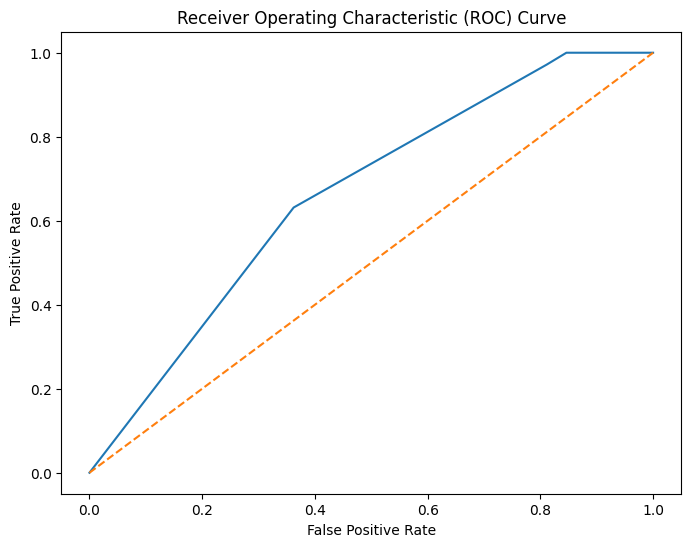

In [52]:
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    roc_auc_score
)

# Predicciones
y_pred = log_reg_model.predict(X_train)
y_prob = log_reg_model.predict_proba(X_train)[:, 1]

# Métricas detalladas
print("\nInforme de Clasificación:")
print(classification_report(y_train, y_pred))

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_train, y_prob)
auc = roc_auc_score(y_train, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()


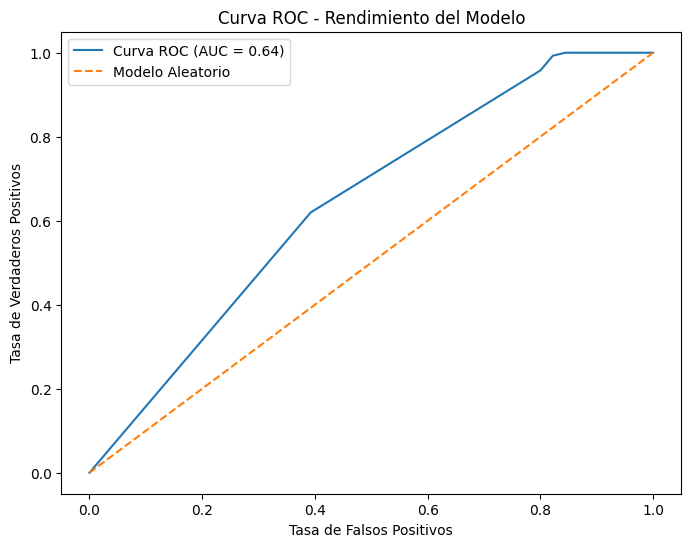

AUC: 0.642357850808555


In [53]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calcular curva ROC
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Visualización
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Modelo Aleatorio')
plt.title('Curva ROC - Rendimiento del Modelo')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.show()

print(f"AUC: {auc}")

### Interpretación del AUC (Área Bajo la Curva)
- AUC = 0.5: Modelo aleatorio
- AUC = 0.7-0.8: Modelo aceptable
- AUC = 0.8-0.9: Modelo bueno
- AUC = 0.9-1.0: Modelo excelente

#### Usando StatsModels para determinar el P-Value

In [55]:
# Añadir constante
X_train_const = sm.add_constant(X_train)

# Modelo de statsmodels
modelo_sm  = sm.Logit(y_train, X_train_const)
resultados = modelo_sm.fit()

# Imprimir resumen completo
print(resultados.summary())

Optimization terminated successfully.
         Current function value: 0.619433
         Iterations 23
                           Logit Regression Results                           
Dep. Variable:               ab_level   No. Observations:                  829
Model:                          Logit   Df Residuals:                      825
Method:                           MLE   Df Model:                            3
Date:                Fri, 12 Dec 2025   Pseudo R-squ.:                  0.1059
Time:                        12:40:11   Log-Likelihood:                -513.51
converged:                       True   LL-Null:                       -574.30
Covariance Type:            nonrobust   LLR p-value:                 3.526e-26
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.2452      0.111     -2.213      0.027      -0.462      -0.028
disciplined     

----

## Usando el modelo original

In [56]:
log_reg_model = LogisticRegression(solver='liblinear', max_iter=100)
result = log_reg_model.fit(X, y)

# Obtener resultados principales
print("Coeficientes:", log_reg_model.coef_)
print("Intercepto:", log_reg_model.intercept_)

# Predicciones
y_pred = log_reg_model.predict(X_train)
y_prob = log_reg_model.predict_proba(X_train)

Coeficientes: [[-0.79555974 -3.15556594  0.80796771]]
Intercepto: [-0.22848905]


#### Usando StatsModels para determinar el P-Value

In [57]:
# Añadir constante
X_train_const = sm.add_constant(X_train)

# Modelo de statsmodels
modelo_sm = sm.Logit(y_train, X_train_const)
resultados = modelo_sm.fit()

# Imprimir resumen completo
print(resultados.summary())

Optimization terminated successfully.
         Current function value: 0.619433
         Iterations 23
                           Logit Regression Results                           
Dep. Variable:               ab_level   No. Observations:                  829
Model:                          Logit   Df Residuals:                      825
Method:                           MLE   Df Model:                            3
Date:                Fri, 12 Dec 2025   Pseudo R-squ.:                  0.1059
Time:                        12:40:23   Log-Likelihood:                -513.51
converged:                       True   LL-Null:                       -574.30
Covariance Type:            nonrobust   LLR p-value:                 3.526e-26
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.2452      0.111     -2.213      0.027      -0.462      -0.028
disciplined     

Con lbfgs:

    Coeficientes: [[-0.79160939 -3.14806066  0.81008207]]
    Intercepto: [-0.23078357]

Con el modelo "inflado":

    Coeficientes: [[-0.94617011 -2.91554248  0.85194691]]
    Intercepto: [-0.25355932]

In [58]:
# Coeficientes e impacto
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': log_reg_model.coef_[0],
    'Impacto': np.abs(log_reg_model.coef_[0])
})
print("\nCoeficientes ordenados por impacto:")
print(coef_df.sort_values('Impacto', ascending=False))



Coeficientes ordenados por impacto:
         Variable  Coeficiente   Impacto
1   Social_smoker    -3.155566  3.155566
2  Social_drinker     0.807968  0.807968
0     disciplined    -0.795560  0.795560


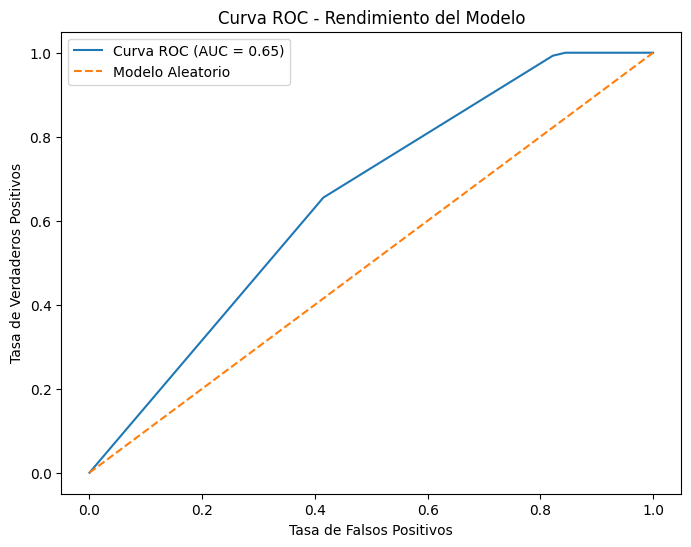

AUC: 0.6491914449660928


In [59]:
# Calcular curva ROC
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Visualización
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Modelo Aleatorio')
plt.title('Curva ROC - Rendimiento del Modelo')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.show()

print(f"AUC: {auc}")

### Análisis de Predictores de Absentismo
#### Contexto del Modelo
Variables Predictoras:

- Disciplinado
- Fumador social
- Bebedor social

Variable Objetivo: **Horas de absentismo**


In [60]:
# Mostrar coeficientes
coef_df = pd.DataFrame({
    'Variable': ['disciplined', 'Social_smoker', 'Social_drinker'],
    'Coeficiente': log_reg_model.coef_[0],
    'Impacto_Absoluto': np.abs(log_reg_model.coef_[0])
})
print(coef_df.sort_values('Impacto_Absoluto', ascending=False))

         Variable  Coeficiente  Impacto_Absoluto
1   Social_smoker    -3.155566          3.155566
2  Social_drinker     0.807968          0.807968
0     disciplined    -0.795560          0.795560


#### Probabilidad de Absentismo

In [61]:
# Función de probabilidad
def interpretar_variable(variable, coeficiente):
    if coeficiente > 0:
        print(f"<b>{variable}</b>: Cuando es 1, AUMENTA la probabilidad de más horas de absentismo")
    else:
        print(f"<b>{variable}</b>: Cuando es 1, DISMINUYE la probabilidad de más horas de absentismo")
    print(f"Magnitud de impacto: {abs(coeficiente):.4f}")

# Aplicar interpretación
for var, coef in zip(['disciplined', 'Social_smoker', 'Social_drinker'], log_reg_model.coef_[0]):
    interpretar_variable(var, coef)


<b>disciplined</b>: Cuando es 1, DISMINUYE la probabilidad de más horas de absentismo
Magnitud de impacto: 0.7956
<b>Social_smoker</b>: Cuando es 1, DISMINUYE la probabilidad de más horas de absentismo
Magnitud de impacto: 3.1556
<b>Social_drinker</b>: Cuando es 1, AUMENTA la probabilidad de más horas de absentismo
Magnitud de impacto: 0.8080


In [62]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix, classification_report

y_pred = log_reg_model.predict(X_train)
print("\nMatriz de Confusión:")
print(confusion_matrix(y_train, y_pred))

print("\nInforme de Clasificación:")
print(classification_report(y_train, y_pred))



Matriz de Confusión:
[[257 146]
 [157 269]]

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.62      0.64      0.63       403
           1       0.65      0.63      0.64       426

    accuracy                           0.63       829
   macro avg       0.63      0.63      0.63       829
weighted avg       0.63      0.63      0.63       829



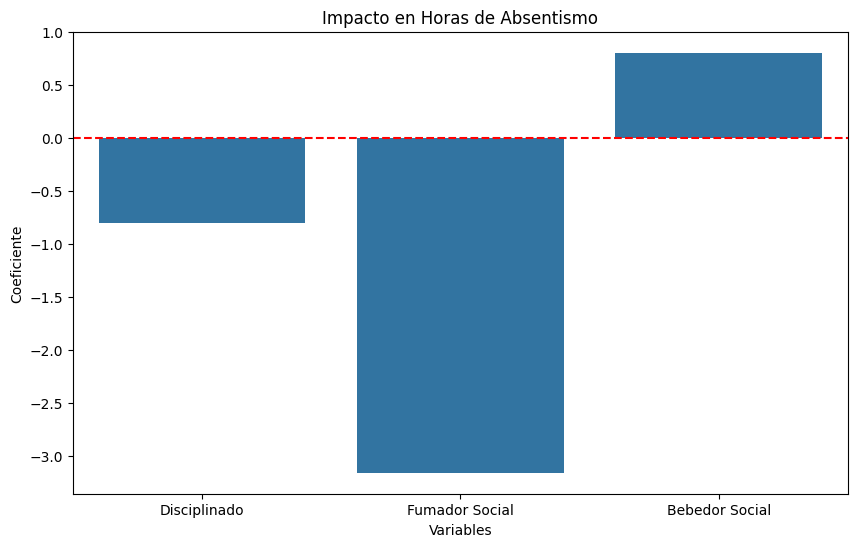

In [63]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=['Disciplinado', 'Fumador Social', 'Bebedor Social'], 
    y=log_reg_model.coef_[0],
)
plt.title('Impacto en Horas de Absentismo')
plt.xlabel('Variables')
plt.ylabel('Coeficiente')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

#### Predicción

In [66]:
# Calcular probabilidad para diferentes combinaciones
def calcular_prob_absentismo(disciplinado, fumador_social, bebedor_social):
    X_ejemplo    = np.array([[disciplinado, fumador_social, bebedor_social]])
    probabilidad = log_reg_model.predict_proba(X_ejemplo)[0][1]
    return probabilidad

# Ejemplos
print("\nProbabilidad de altas horas de absentismo:")
print("Persona disciplinada, no fumadora, no bebedora:")
print(calcular_prob_absentismo(1, 0, 0))# Función para calcular probabilidad

def calcular_probabilidad(x, coef, intercepto):
    z = np.dot(x, coef) + intercepto
    return 1 / (1 + np.exp(-z))

# Ejemplo con una observación
observacion  = X_train.iloc[0]
coeficientes = log_reg_model.coef_[0]
intercepto   = log_reg_model.intercept_
probabilidad = calcular_probabilidad(observacion, coeficientes, intercepto)
print("\nProbabilidad para esta observación:", probabilidad)


print("\nPersona no disciplinada, fumadora, bebedora:")
print(calcular_prob_absentismo(0, 1, 1))



Probabilidad de altas horas de absentismo:
Persona disciplinada, no fumadora, no bebedora:
0.26423949617778303

Probabilidad para esta observación: [0.64094744]

Persona no disciplinada, fumadora, bebedora:
0.07069334913147456


/home/nicamlg/Projects/DataAnalytics/ProjecteData/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/nicamlg/Projects/DataAnalytics/ProjecteData/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
